In [1]:
import pandas as pd
import matplotlib.pyplot as plt

misc_for = pd.read_csv(
    r"../data/overwiev__stats_squads_misc_for.csv"
)

misc_for.head()

,Squad,# Pl,90s,Performance_CrdY,Performance_CrdR,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_PKcon,Performance_OG
0,Arsenal,25,38.0,70,6,3,401,405,80,766,225,348,2,3,0
1,Aston Villa,28,38.0,76,4,2,406,499,55,604,240,372,6,3,0
2,Bournemouth,29,38.0,97,3,0,525,400,70,832,351,399,7,4,0
3,Brentford,28,38.0,62,1,0,320,339,63,674,285,380,6,1,3
4,Brighton,32,38.0,78,3,2,438,411,46,704,315,431,6,9,2


In [2]:
misc_for = misc_for.rename(columns={
    "Squad": "team",
    "# Pl": "players_used",
    "Performance_CrdY": "yellow_cards",
    "Performance_CrdR": "red_cards",
    "Performance_2CrdY": "second_yellow",
    "Performance_Fls": "fouls_committed",
    "Performance_Fld": "fouls_drawn",
    "Performance_Off": "offsides",
    "Performance_Crs": "crosses",
    "Performance_Int": "interceptions",
    "Performance_TklW": "tackles_won"
})

misc_for["team"] = misc_for["team"].str.strip()

misc_for.head()

,team,players_used,90s,yellow_cards,red_cards,second_yellow,fouls_committed,fouls_drawn,offsides,crosses,interceptions,tackles_won,Performance_PKwon,Performance_PKcon,Performance_OG
0,Arsenal,25,38.0,70,6,3,401,405,80,766,225,348,2,3,0
1,Aston Villa,28,38.0,76,4,2,406,499,55,604,240,372,6,3,0
2,Bournemouth,29,38.0,97,3,0,525,400,70,832,351,399,7,4,0
3,Brentford,28,38.0,62,1,0,320,339,63,674,285,380,6,1,3
4,Brighton,32,38.0,78,3,2,438,411,46,704,315,431,6,9,2


In [4]:
#discipline_index = yellow_cards + (red_cards * 2)
misc_for["discipline_index"] = (
    misc_for["yellow_cards"] +
    misc_for["red_cards"] * 2
)

In [5]:
misc_for["aggression_index"] = (
    misc_for["fouls_committed"] +
    misc_for["tackles_won"] +
    misc_for["interceptions"]
)

In [6]:
aggressive_rank = misc_for.sort_values(
    by="aggression_index",
    ascending=False
)

aggressive_rank[[
    "team",
    "aggression_index"
]]

,team,aggression_index
2,Bournemouth,1275
13,Manchester Utd,1254
19,Wolves,1249
7,Everton,1208
6,Crystal Palace,1201
4,Brighton,1184
17,Tottenham Hotspur,1182
10,Leicester City,1178
18,West Ham United,1162
8,Fulham,1145


In [7]:
discipline_rank = misc_for.sort_values(
    by="discipline_index",
    ascending=True
)

discipline_rank[[
    "team",
    "discipline_index"
]]

,team,discipline_index
12,Manchester City,63
3,Brentford,64
14,Newcastle United,70
11,Liverpool,73
17,Tottenham Hotspur,74
0,Arsenal,82
19,Wolves,83
8,Fulham,84
1,Aston Villa,84
4,Brighton,84


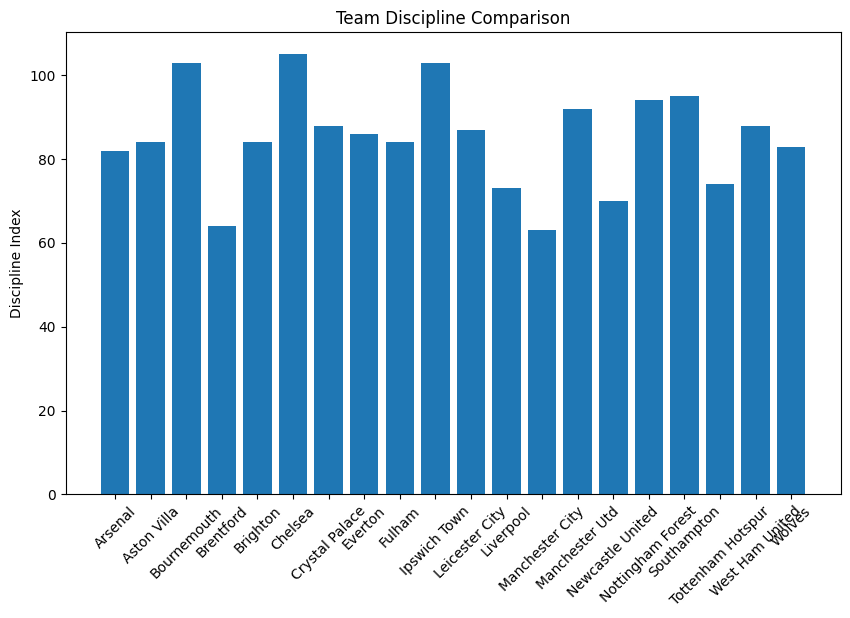

In [8]:
plt.figure(figsize=(10,6))

plt.bar(
    misc_for["team"],
    misc_for["discipline_index"]
)

plt.xticks(rotation=45)
plt.ylabel("Discipline Index")
plt.title("Team Discipline Comparison")

plt.show()

In [9]:
misc_for[[
    "aggression_index",
    "discipline_index"
]].corr()

,aggression_index,discipline_index
aggression_index,1.000000,0.520834
discipline_index,0.520834,1.000000


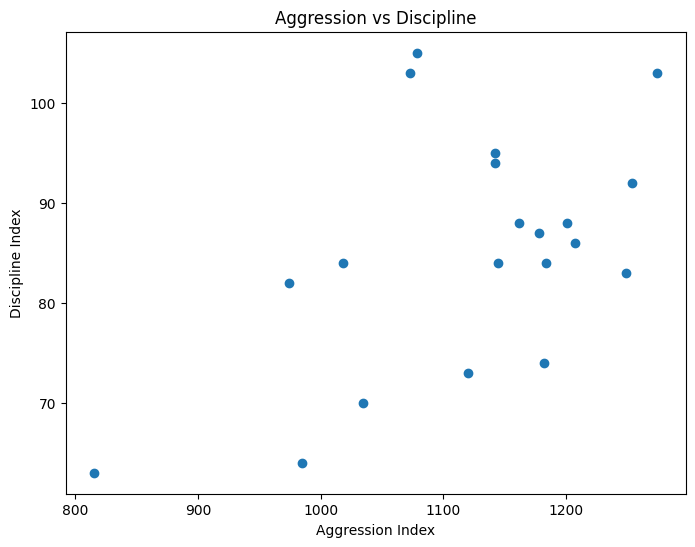

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    misc_for["aggression_index"],
    misc_for["discipline_index"]
)

plt.xlabel("Aggression Index")
plt.ylabel("Discipline Index")
plt.title("Aggression vs Discipline")

plt.show()